# AnalystLab Africa — Data Science Internship Programme
## Week 3: Advanced Data Analysis, Statistical Validation & Feature Engineering

**Dataset:** Heart Failure Prediction Dataset (fedesoriano, Kaggle) — continued from Week 2
**Objective:** Deepen the investigation of the cleaned dataset before predictive modelling begins in Week 4.
**Role:** Junior Data Scientist, AnalystLab Africa Consulting

This notebook continues directly from the Week 2 cleaned dataset (`heart_cleaned.csv`). The full
Week 2 cleaning process (missing-value treatment, duplicate removal, data-type correction) is **not**
repeated here — only decisions with new evidence from this week's analysis are revisited.

### Workflow
1. Project Continuity Summary
2. Advanced Exploratory Data Analysis
3. Statistical Hypothesis Testing & Validation
4. Advanced Feature Engineering
5. Feature Evaluation & Selection
6. Dataset Refinement — Final Modelling Dataset
7. Business Insights Summary


## 📦 1. Setup & Data Loading

In this step, we import essential Python libraries required for data manipulation, numerical analysis, and data visualization:
* **NumPy:** For high-level mathematical and array operations.
* **Pandas:** For loading, processing, and cleaning structured datasets.
* **Matplotlib & Seaborn:** For generating clean statistical charts and visualizations.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

: 

In [ ]:
1 + 1

: 

### 🔍 1.1 Loading the dataset

The dataset was download from the week 2 cleaned dataset on heart prediction analysis.

In [4]:

df = pd.read_csv('C:\\Users\\Ange\\Downloads\\Training Data S. africa Lab\\week 2\\Data cleaned\\heart_cleaned.csv')
print(f"Loaded Week 2 cleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded Week 2 cleaned dataset: 918 rows, 14 columns


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,HR_Reserve
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,<40,8
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,40-49,15
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,<40,85
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,40-49,64
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,50-59,44


In [13]:
df.info

<bound method DataFrame.info of      Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  \
0     40   M           ATA      140.0        289.0          0     Normal   
1     49   F           NAP      160.0        180.0          0     Normal   
2     37   M           ATA      130.0        283.0          0         ST   
3     48   F           ASY      138.0        214.0          0     Normal   
4     54   M           NAP      150.0        195.0          0     Normal   
..   ...  ..           ...        ...          ...        ...        ...   
913   45   M            TA      110.0        264.0          0     Normal   
914   68   M           ASY      144.0        193.0          1     Normal   
915   57   M           ASY      130.0        131.0          0     Normal   
916   57   F           ATA      130.0        236.0          0        LVH   
917   38   M           NAP      138.0        175.0          0     Normal   

     MaxHR ExerciseAngina  Oldpeak ST_Slope  HeartDisea

## Part 1: Project Continuity Summary

**Business problem.** AnalystLab Africa Consulting is supporting a healthcare analytics initiative to
identify patients at risk of heart disease earlier and more consistently than manual clinical judgement
alone allows.

**Project objective.** Prepare and analyse a combined clinical dataset (918 patients, 11 core features)
so that a predictive model can classify whether a patient is likely to have heart disease.

**Target variable.** `HeartDisease`,  binary (1 = disease, 0 = no disease), confirmed in Week 1/2 as
reasonably balanced (55.3% positive, 44.7% negative).

**Key findings from Week 1.** Initial EDA showed clear separation between diagnosis groups on several
features (chest pain type, exercise-induced angina, ST slope), and flagged `Cholesterol` and `RestingBP`
as containing suspicious zero values.

**Major data-quality issues identified in Week 1.** Zero values in `Cholesterol` (18.7% of rows) and
`RestingBP` (1 row) that are physiologically impossible and function as disguised missing data.

**Major cleaning/preprocessing actions completed in Week 2.**
- Zero values in `Cholesterol`/`RestingBP` replaced with `NaN` and median-imputed by `HeartDisease` group.
- No duplicate rows found; categorical columns cast to `category` dtype.
- Engineered `AgeGroup` and `HR_Reserve`; `HR_Reserve` was later found to be ~93% correlated with `MaxHR`
  (a mechanical artefact of its formula) and excluded from the machine-learning-ready dataset.
- Dataset encoded (label/ordinal/one-hot) and scaled (`StandardScaler`) for a machine-learning-ready
  version; **this notebook continues from the pre-encoding cleaned version**, since Week 3 analysis
  benefits from readable categorical labels and raw numeric scales.

**Remaining questions for deeper investigation this week.**
- Are the visual separations seen in Week 1/2 statistically significant, or could they be due to chance?
- Do clinically meaningful risk bands (cholesterol, blood pressure) add information beyond the raw
  continuous values?
- Does combining several individual risk indicators into one aggregated feature reveal a stronger signal
  than any single feature alone?
- Which features are genuinely redundant once both correlation *and* predictive value are considered?


## Part 2:  Advanced Exploratory Data Analysis

This section goes beyond the Week 1 EDA, focusing on distribution shape, group comparisons, and
multivariate relationships not fully explored previously.

### 2.1 Numerical analysis — distribution shape & skewness

In [5]:
cont_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
skew_table = df[cont_vars].skew().sort_values(ascending=False).rename('Skewness').to_frame()
skew_table['Interpretation'] = skew_table['Skewness'].apply(
    lambda s: 'Highly skewed' if abs(s) > 1 else ('Moderately skewed' if abs(s) > 0.5 else 'Approx. symmetric')
)
skew_table


,Skewness,Interpretation
Cholesterol,1.373524,Highly skewed
Oldpeak,1.022872,Highly skewed
RestingBP,0.607622,Moderately skewed
MaxHR,-0.144359,Approx. symmetric
Age,-0.195933,Approx. symmetric


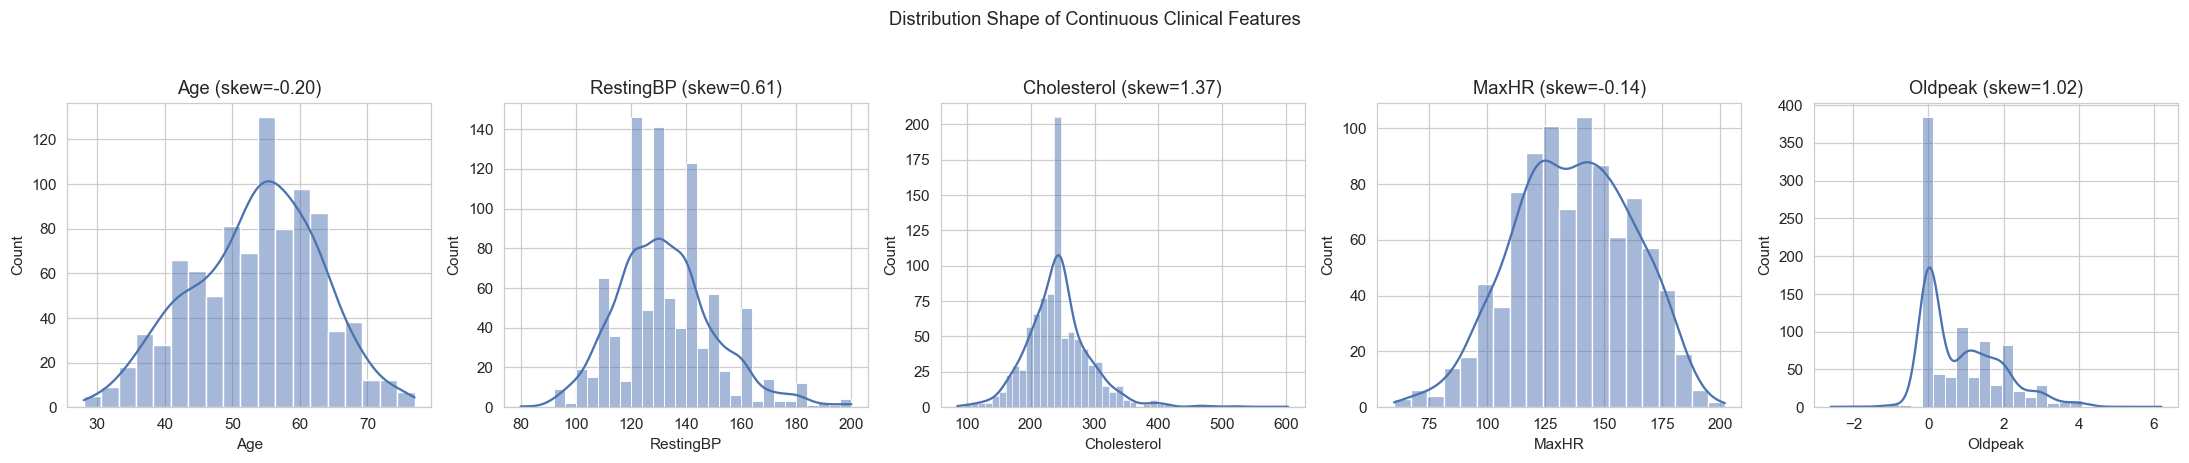

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, cont_vars):
    sns.histplot(df[col], kde=True, ax=ax, color='#4C72B0')
    ax.set_title(f'{col} (skew={df[col].skew():.2f})')
fig.suptitle('Distribution Shape of Continuous Clinical Features', y=1.04)
plt.tight_layout()
plt.show()

`Cholesterol` and `Oldpeak` are the most skewed continuous features (skew > 1), which motivates the
log-transform of `Oldpeak` explored in Part 4 (Feature Engineering).

### 2.2 Numerical vs. target — violin plots

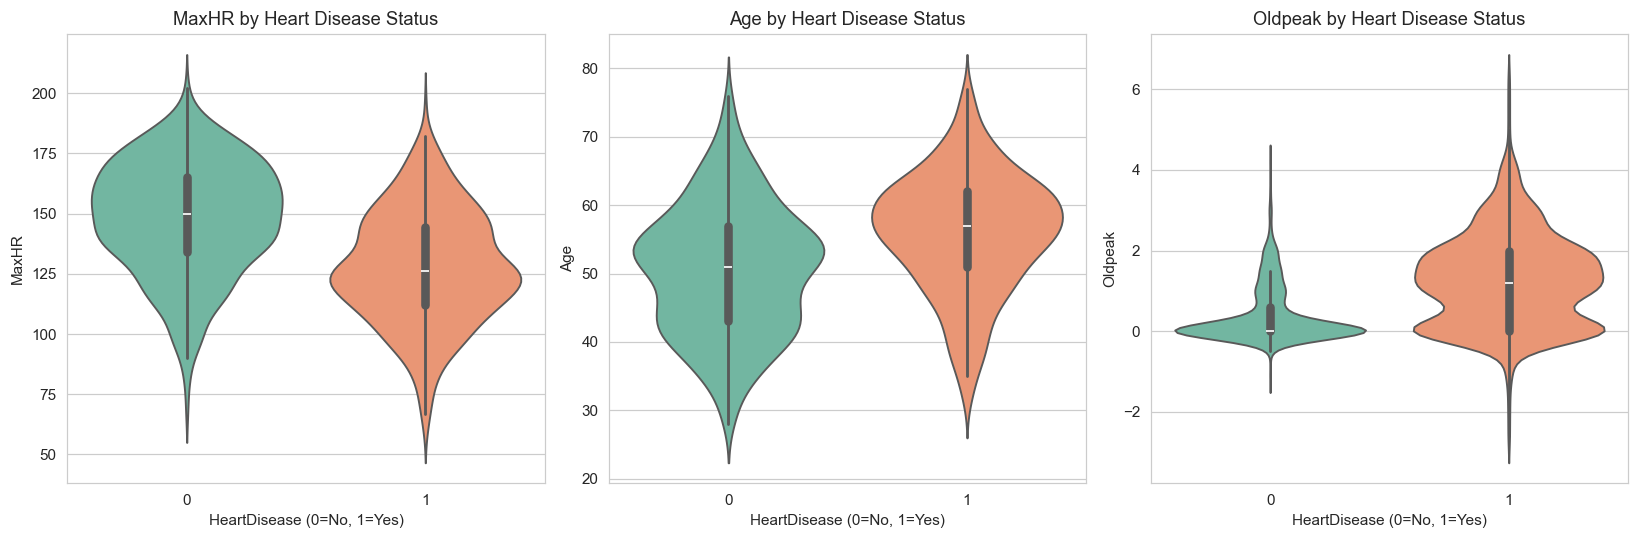

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ['MaxHR', 'Age', 'Oldpeak']):
    sns.violinplot(data=df, x='HeartDisease', y=col, hue='HeartDisease',
                    palette='Set2', ax=ax, legend=False)
    ax.set_title(f'{col} by Heart Disease Status')
    ax.set_xlabel('HeartDisease (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

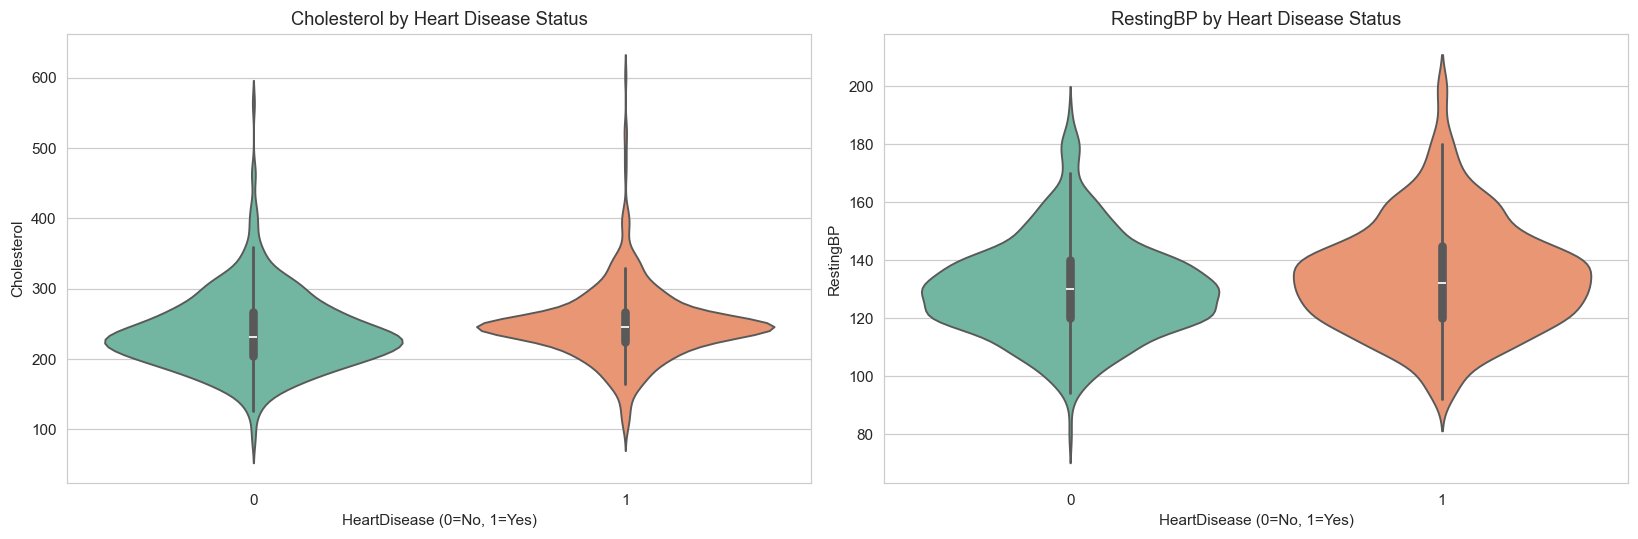

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, col in zip(axes, ['Cholesterol', 'RestingBP']):
    sns.violinplot(data=df, x='HeartDisease', y=col, hue='HeartDisease',
                    palette='Set2', ax=ax, legend=False)
    ax.set_title(f'{col} by Heart Disease Status')
    ax.set_xlabel('HeartDisease (0=No, 1=Yes)')
plt.tight_layout()
plt.show()

Patients with heart disease show a visibly lower median `MaxHR`, a somewhat older age distribution,
and a distribution of `Oldpeak` shifted toward higher values — all consistent with established
cardiology risk patterns and formally tested in Part 3.

### 2.3 Categorical analysis — frequency & percentage breakdowns

In [9]:
cat_vars = ['ChestPainType', 'RestingECG', 'ST_Slope', 'ExerciseAngina', 'Sex']
for col in cat_vars:
    pct = df[col].value_counts(normalize=True).round(3) * 100
    print(f"--- {col} (% of patients) ---")
    print(pct.astype(str) + '%')
    print()


--- ChestPainType (% of patients) ---
ChestPainType
ASY    54.0%
NAP    22.1%
ATA    18.8%
TA      5.0%
Name: proportion, dtype: object

--- RestingECG (% of patients) ---
RestingECG
Normal    60.099999999999994%
LVH                     20.5%
ST        19.400000000000002%
Name: proportion, dtype: object

--- ST_Slope (% of patients) ---
ST_Slope
Flat    50.1%
Up      43.0%
Down     6.9%
Name: proportion, dtype: object

--- ExerciseAngina (% of patients) ---
ExerciseAngina
N    59.599999999999994%
Y    40.400000000000006%
Name: proportion, dtype: object

--- Sex (% of patients) ---
Sex
M    79.0%
F    21.0%
Name: proportion, dtype: object



### 2.4 Categorical vs. target — stacked bar charts (proportions)

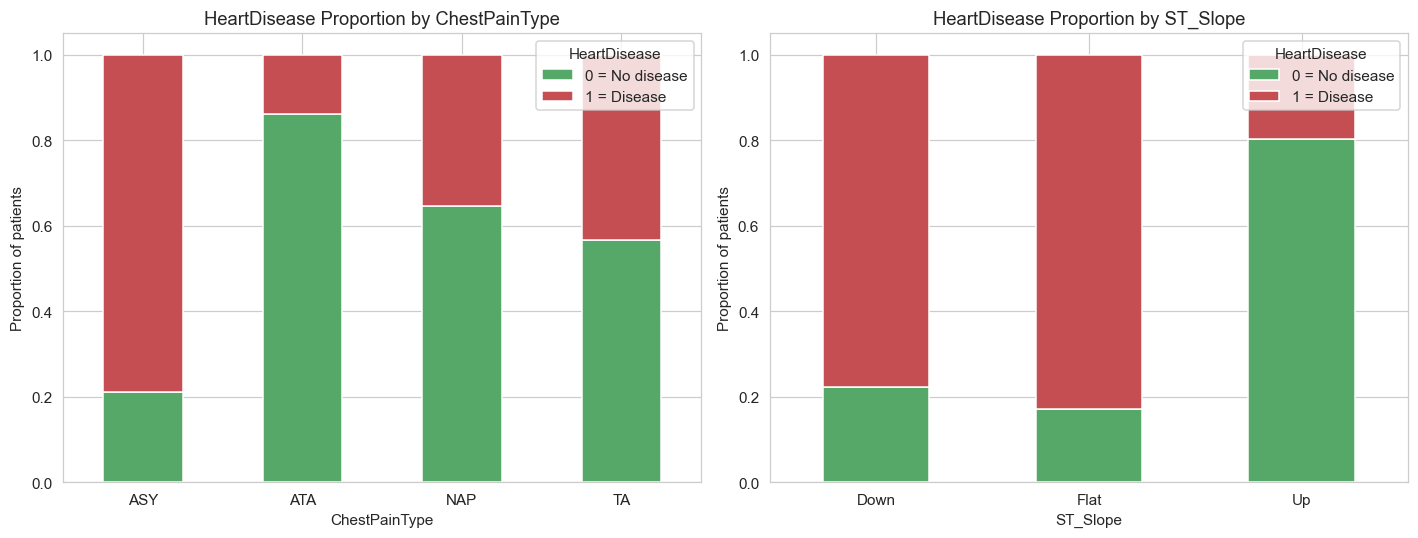

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ['ChestPainType', 'ExerciseAngina']):
    props = pd.crosstab(df[col], df['HeartDisease'], normalize='index')
    props.plot(kind='bar', stacked=True, ax=ax, color=['#55A868', '#C44E52'])
    ax.set_title(f'HeartDisease Proportion by {col}')
    ax.set_ylabel('Proportion of patients')
    ax.legend(title='HeartDisease', labels=['0 = No disease', '1 = Disease'])
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


`ChestPainType = ASY` (asymptomatic) carries the highest disease proportion (~79%), and
`ST_Slope = Flat` also carries a markedly higher disease proportion than `Up` 

both patterns areformally tested with Chi-Square in Part 3.

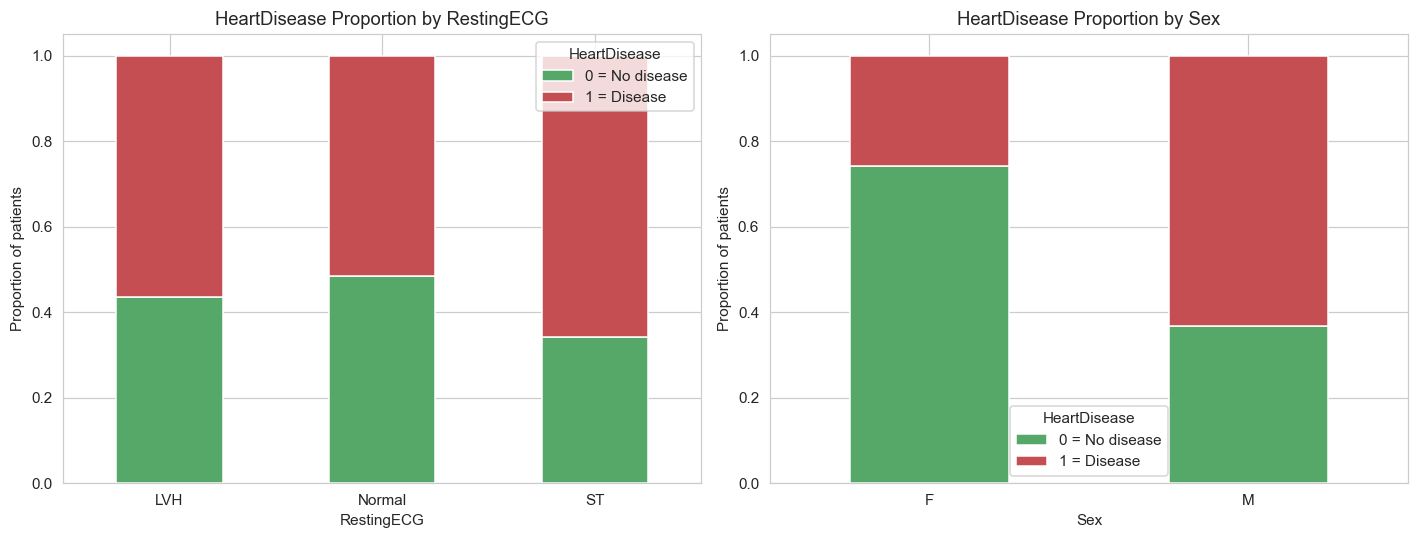

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, ['RestingECG', "Sex"]):
    props = pd.crosstab(df[col], df['HeartDisease'], normalize='index')
    props.plot(kind='bar', stacked=True, ax=ax, color=['#55A868', '#C44E52'])
    ax.set_title(f'HeartDisease Proportion by {col}')
    ax.set_ylabel('Proportion of patients')
    ax.legend(title='HeartDisease', labels=['0 = No disease', '1 = Disease'])
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Male caries the highest disease proportion compared to female (62%)

### 2.5 Bivariate analysis — numerical vs. numerical

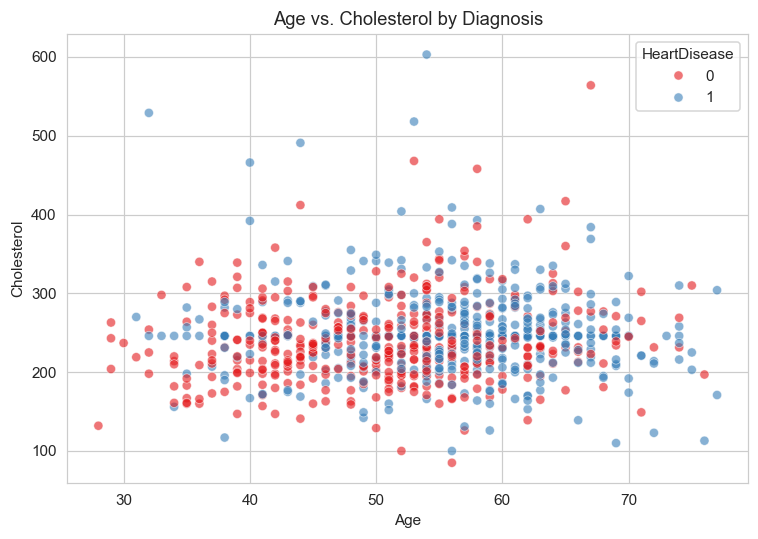

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x='Age', y='Cholesterol', hue='HeartDisease', palette='Set1', alpha=0.6, ax=ax)
ax.set_title('Age vs. Cholesterol by Diagnosis')
plt.tight_layout()
plt.show()


### 2.6 Bivariate analysis — numerical vs. categorical (boxplot)

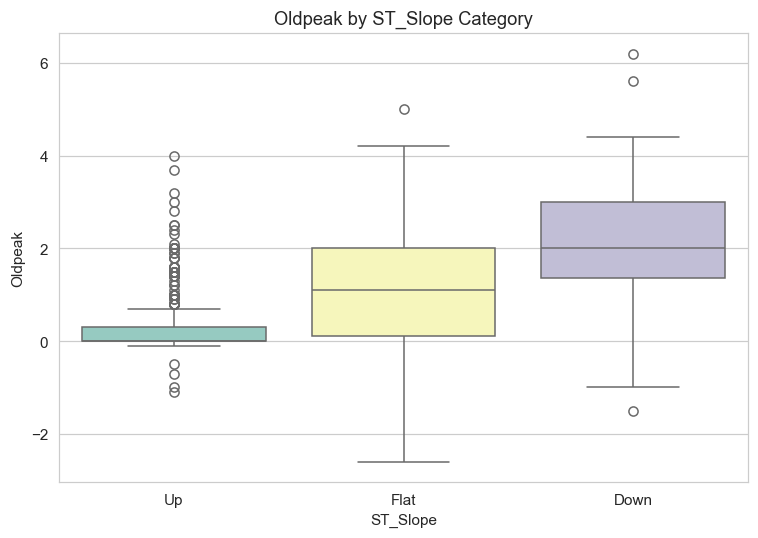

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='ST_Slope', y='Oldpeak', hue='ST_Slope', palette='Set3', ax=ax, legend=False)
ax.set_title('Oldpeak by ST_Slope Category')
plt.tight_layout()
plt.show()

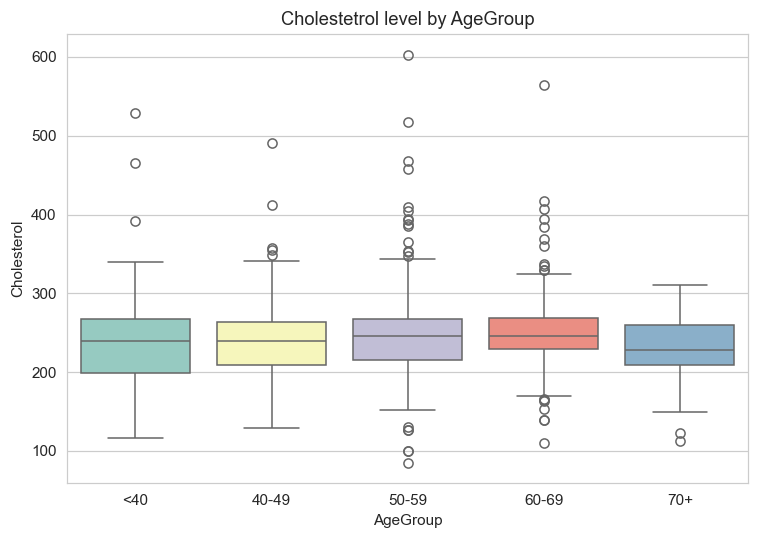

In [23]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='AgeGroup', y='Cholesterol', hue='AgeGroup', palette='Set3', ax=ax, legend=False)
ax.set_title('Cholestetrol level by AgeGroup')
plt.tight_layout()
plt.show()

### 2.7 Bivariate analysis — categorical vs. categorical (cross-tab heatmap)

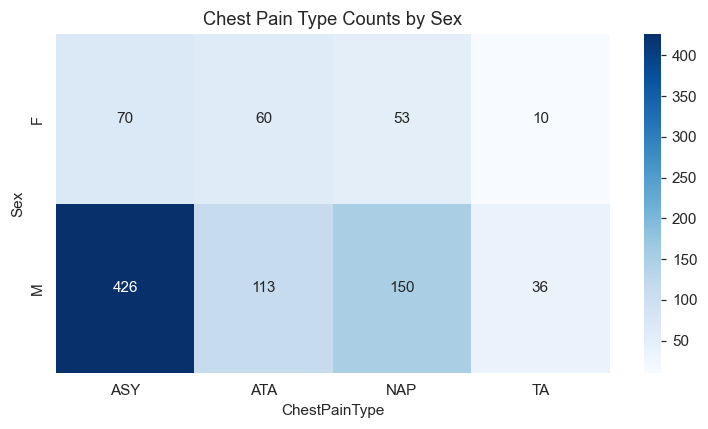

In [ ]:
ct = pd.crosstab(df['Sex'], df['ChestPainType'])
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Chest Pain Type Counts by Sex')
plt.tight_layout()
plt.show()

### 2.8 Multivariate analysis: grouped pivot table & heatmap

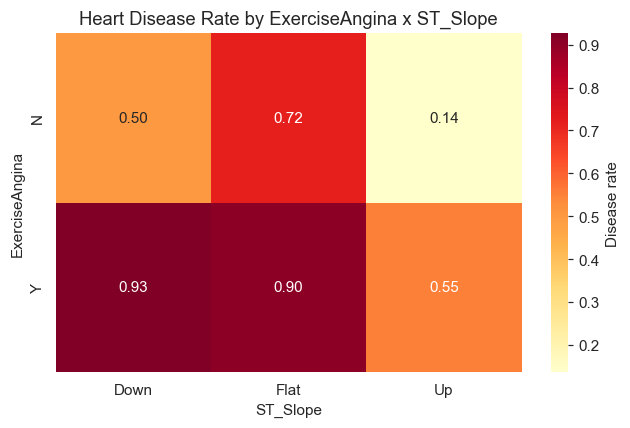

ST_Slope,Down,Flat,Up
ExerciseAngina,,,
N,0.500,0.718,0.136
Y,0.927,0.904,0.552


In [ ]:
pivot = df.pivot_table(values='HeartDisease', index='ExerciseAngina', columns='ST_Slope', aggfunc='mean')
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Disease rate'})
ax.set_title('Heart Disease Rate by ExerciseAngina x ST_Slope')
plt.tight_layout()
plt.show()
pivot.round(3)

Patients with **both** exercise-induced angina and a `Flat`/`Down` ST slope show the highest observed
disease rates — a compounding, multivariate risk pattern not visible from either variable alone.

### 2.9 Multivariate analysis — scatter matrix (pair plot)

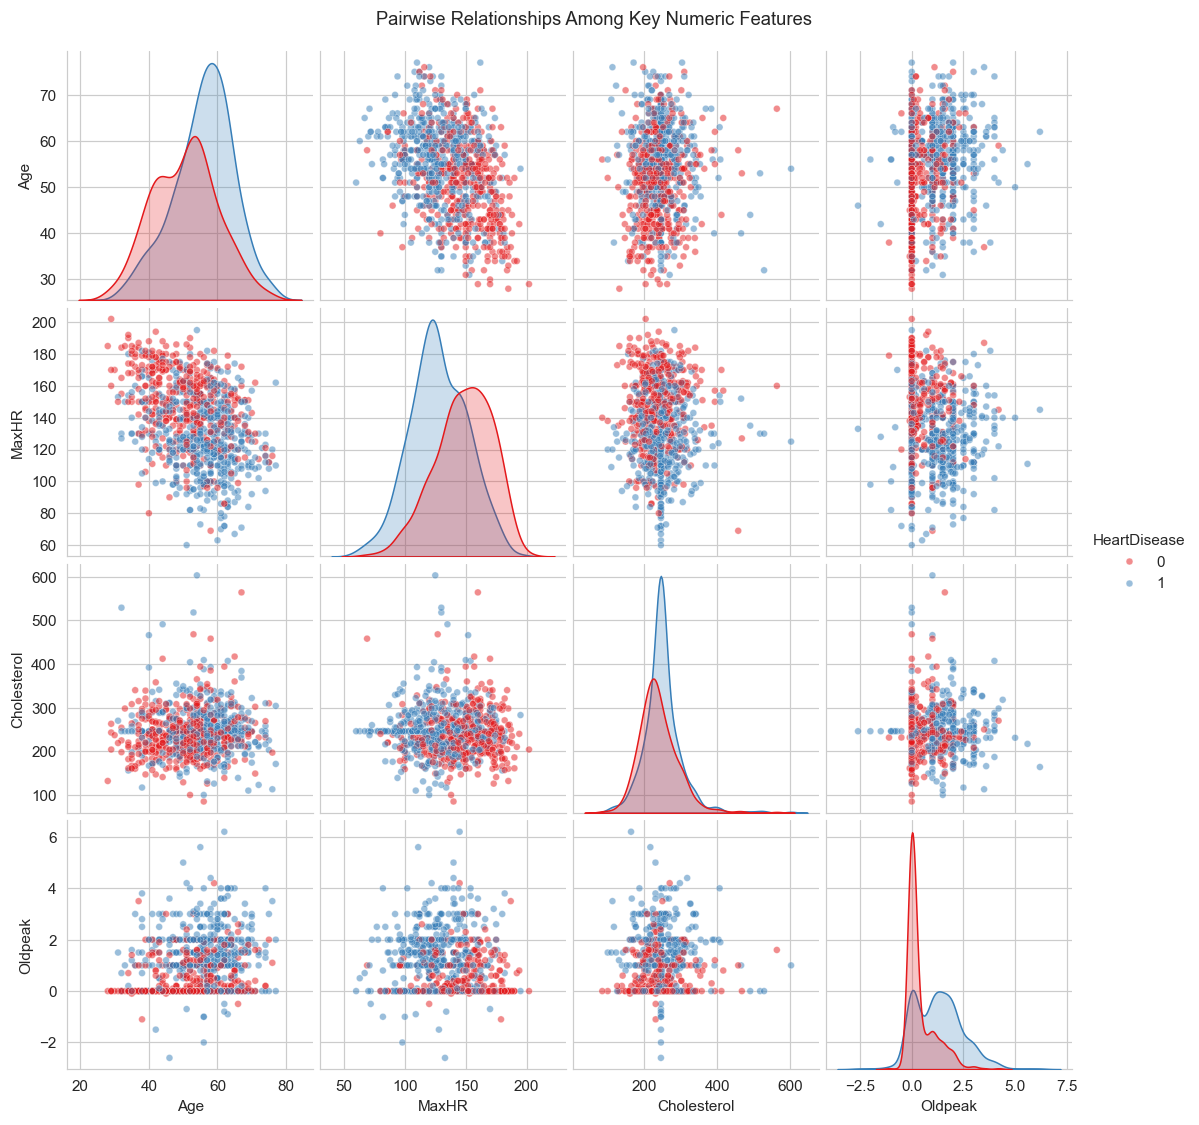

In [26]:
pair_cols = ['Age', 'MaxHR', 'Cholesterol', 'Oldpeak', 'HeartDisease']
g = sns.pairplot(df[pair_cols], hue='HeartDisease', palette='Set1', diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 20})
g.fig.suptitle('Pairwise Relationships Among Key Numeric Features', y=1.02)
plt.show()

### 2.10 Correlation analysis (numeric + ordinal/binary features)

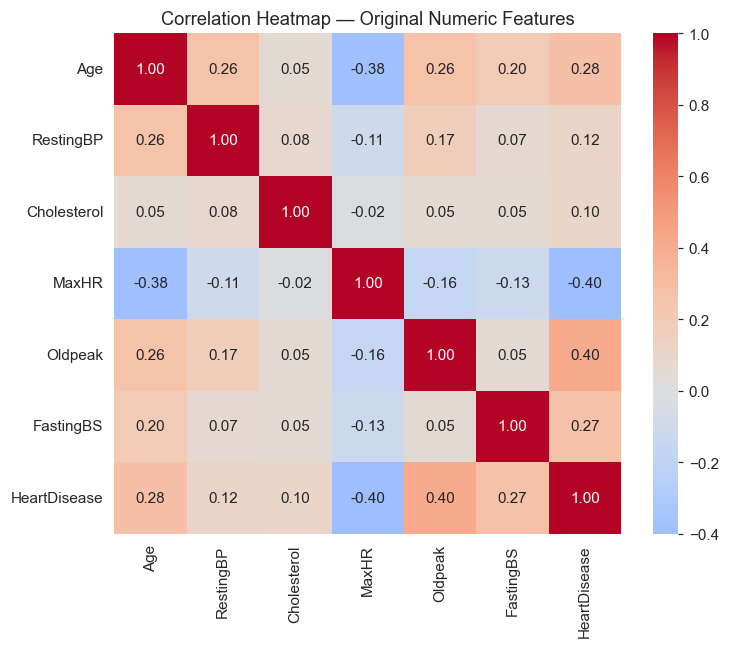

In [28]:
corr_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'FastingBS', 'HeartDisease']
corr = df[corr_vars].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap — Original Numeric Features')
plt.tight_layout()
plt.show()

## Part 3 — Statistical Hypothesis Testing & Validation

Shapiro-Wilk normality tests (below) confirm that none of the continuous clinical features are normally
distributed (all p < 0.05 on a 500-row sample), which motivates the use of **non-parametric tests**
(Mann-Whitney U, Kruskal-Wallis) for numeric comparisons rather than assuming normality for a t-test.

In [29]:
print("=== Shapiro-Wilk normality tests (sample of 500) ===")
for col in cont_vars:
    stat, p = stats.shapiro(df[col].sample(min(500, len(df)), random_state=RANDOM_STATE))
    verdict = "NOT normal (reject H0 of normality)" if p < 0.05 else "consistent with normal"
    print(f"{col:>12}: W={stat:.4f}, p={p:.6f} -> {verdict}")


=== Shapiro-Wilk normality tests (sample of 500) ===
         Age: W=0.9909, p=0.003633 -> NOT normal (reject H0 of normality)
   RestingBP: W=0.9728, p=0.000000 -> NOT normal (reject H0 of normality)
 Cholesterol: W=0.9157, p=0.000000 -> NOT normal (reject H0 of normality)
       MaxHR: W=0.9906, p=0.002906 -> NOT normal (reject H0 of normality)
     Oldpeak: W=0.8651, p=0.000000 -> NOT normal (reject H0 of normality)


### Test 1-Mann-Whitney U: Cholesterol by HeartDisease status

**Business question.** Do patients with heart disease have meaningfully different cholesterol levels
than patients without it?

**Objective.** Compare the distribution of `Cholesterol` between the two `HeartDisease` groups.

**H0:** The distribution of `Cholesterol` is the same for both `HeartDisease` groups.

**H1:** The distribution of `Cholesterol` differs between the two `HeartDisease` groups.

**Method chosen:** Mann-Whitney U test: `Cholesterol` is non-normally distributed (confirmed above) and
right-skewed, so a rank-based test is more appropriate than a t-test.

In [30]:
hd0 = df[df['HeartDisease'] == 0]
hd1 = df[df['HeartDisease'] == 1]

u1, p1 = stats.mannwhitneyu(hd0['Cholesterol'], hd1['Cholesterol'], alternative='two-sided')
print(f"U statistic = {u1:.1f}, p-value = {p1:.6f}")
print(f"Median Cholesterol — No disease: {hd0['Cholesterol'].median():.1f} | Disease: {hd1['Cholesterol'].median():.1f}")


U statistic = 85712.5, p-value = 0.000004
Median Cholesterol — No disease: 231.5 | Disease: 246.0


**Decision.** p < 0.05 → reject H0.

 **Interpretation.** Cholesterol levels differ significantly
between groups, with patients diagnosed with heart disease showing a higher median cholesterol
(246.0 vs. 231.5).

 **Business implication.** Cholesterol screening remains a meaningful, statistically
supported risk-stratification signal for this population and should be retained as a modelling feature.

### Test 2-Mann-Whitney U: MaxHR by HeartDisease status

**Business question.** Is maximum heart rate achieved during exercise associated with a heart disease
diagnosis?

**Objective.** Compare `MaxHR` distributions across `HeartDisease` groups.

**H0:** The distribution of `MaxHR` is the same for both groups.

**H1:** The distribution of `MaxHR` differs between groups.

**Method chosen:** Mann-Whitney U test, for the same non-normality reason as Test 1.

In [31]:
u2, p2 = stats.mannwhitneyu(hd0['MaxHR'], hd1['MaxHR'], alternative='two-sided')
print(f"U statistic = {u2:.1f}, p-value = {p2:.6f}")
print(f"Median MaxHR — No disease: {hd0['MaxHR'].median():.0f} | Disease: {hd1['MaxHR'].median():.0f}")


U statistic = 153089.5, p-value = 0.000000
Median MaxHR — No disease: 150 | Disease: 126


**Decision.** p < 0.05 → reject H0. 

**Interpretation.** Patients with heart disease reach a
substantially lower maximum heart rate (median 126 vs. 150),  consistent with reduced cardiovascular
exercise capacity in affected patients.

 **Business implication.** `MaxHR` is a strong, statistically
validated candidate feature and a low-cost, non-invasive measurement clinics can prioritise collecting.

### Test 3-Chi-Square Test of Independence: ChestPainType vs. HeartDisease

**Business question.** Is the type of chest pain a patient reports associated with their heart disease
diagnosis?

**Objective.** Test whether `ChestPainType` and `HeartDisease` are statistically independent.

**H0:** `ChestPainType` and `HeartDisease` are independent.

**H1:** `ChestPainType` and `HeartDisease` are associated.

**Method chosen:** Chi-Square test of independence, both variables are categorical/nominal.

In [32]:
ct_cp = pd.crosstab(df['ChestPainType'], df['HeartDisease'])
chi2_cp, p_cp, dof_cp, _ = stats.chi2_contingency(ct_cp)
print(ct_cp)
print(f"\nchi2 = {chi2_cp:.2f}, dof = {dof_cp}, p-value = {p_cp:.2e}")


HeartDisease     0    1
ChestPainType          
ASY            104  392
ATA            149   24
NAP            131   72
TA              26   20

chi2 = 268.07, dof = 3, p-value = 8.08e-58


**Decision.** p < 0.05 → reject H0. 

**Interpretation.** Chest pain type is strongly associated with
diagnosis: patients reporting `ASY` (asymptomatic) chest pain have a markedly higher disease rate (79%)
than those reporting `ATA` (14%). 

**Business implication.** Counter-intuitively, the *absence* of typical
chest pain is the strongest chest-pain-related warning sign in this data,  a message worth communicating
clearly to clinicians who may otherwise deprioritise asymptomatic patients.

### Test 4- Chi-Square Test of Independence: ExerciseAngina vs. HeartDisease

**Business question.** Is exercise-induced angina associated with a heart disease diagnosis?

**H0:** `ExerciseAngina` and `HeartDisease` are independent.

**H1:** `ExerciseAngina` and `HeartDisease` are associated.

**Method chosen:** Chi-Square test of independence- both variables are binary/categorical.

In [33]:
ct_ang = pd.crosstab(df['ExerciseAngina'], df['HeartDisease'])
chi2_ang, p_ang, dof_ang, _ = stats.chi2_contingency(ct_ang)
print(ct_ang)
print(f"\nchi2 = {chi2_ang:.2f}, dof = {dof_ang}, p-value = {p_ang:.2e}")


HeartDisease      0    1
ExerciseAngina          
N               355  192
Y                55  316

chi2 = 222.26, dof = 1, p-value = 2.91e-50


**Decision.** p < 0.05 → reject H0. 

**Interpretation.** Exercise-induced angina is strongly
associated with diagnosis - 85% of patients who report angina during exercise (316 of 371) have heart
disease, versus 35% of those who do not. 

**Business implication.** A simple yes/no question asked during
a routine stress test carries substantial diagnostic signal and is a cheap, fast screening item.

### Test 5- Kruskal-Wallis Test: Oldpeak across ST_Slope groups

**Business question.** Does the amount of exercise-induced ST depression (`Oldpeak`) differ across the
three `ST_Slope` categories (Up, Flat, Down)?

**Objective.** Compare `Oldpeak` across three independent groups.

**H0:** The distribution of `Oldpeak` is the same across all `ST_Slope` categories.

**H1:** At least one `ST_Slope` category has a different `Oldpeak` distribution.

**Method chosen:** Kruskal-Wallis H test - three groups being compared, `Oldpeak` is non-normal and
right-skewed, so the non-parametric ANOVA alternative is appropriate.

In [34]:
groups = [g['Oldpeak'].values for _, g in df.groupby('ST_Slope', observed=True)]
h_stat, p_kw = stats.kruskal(*groups)
print(df.groupby('ST_Slope', observed=True)['Oldpeak'].median())
print(f"\nH statistic = {h_stat:.2f}, p-value = {p_kw:.2e}")


ST_Slope
Down    2.0
Flat    1.1
Up      0.0
Name: Oldpeak, dtype: float64

H statistic = 245.96, p-value = 3.90e-54


**Decision.** p < 0.05 → reject H0. 

**Interpretation.** Median `Oldpeak` rises sharply from `Up`
(0.0) to `Flat` (1.1) to `Down` (2.0), confirming ST slope shape is strongly linked to the magnitude of
exercise-induced ST depression.

 **Business implication.** These two exercise-test-derived features
jointly reflect the same underlying cardiac stress response and should be interpreted together in any
clinical or modelling narrative.

### Test 6 - Spearman Correlation: Age vs. MaxHR

**Business question.** Does maximum heart rate achieved decline with patient age, independent of
disease status?

**Objective.** Test the monotonic association between `Age` and `MaxHR`.

**H0:** There is no monotonic association between `Age` and `MaxHR` (ρ = 0).

**H1:** There is a monotonic association between `Age` and `MaxHR` (ρ ≠ 0).

**Method chosen:** Spearman rank correlation - both variables are continuous but non-normal, so a
rank-based correlation is more robust than Pearson's.

In [35]:
rho, p_rho = stats.spearmanr(df['Age'], df['MaxHR'])
print(f"Spearman rho = {rho:.3f}, p-value = {p_rho:.2e}")

Spearman rho = -0.365, p-value = 2.58e-30


**Decision.** p < 0.05 → reject H0. 

**Interpretation.** A moderate negative association (ρ ≈ −0.37)
confirms maximum heart rate tends to decline with age, an expected physiological pattern.

 **Business implication.** Any `MaxHR`-based risk threshold used clinically or in a model should ideally be
age-adjusted rather than applied as a single fixed cut-off across all patients.

## Part 4: Advanced Feature Engineering

Four new features are engineered, each motivated by a specific finding from Parts 2–3 above.

### 4.1 `Cholesterol_Category` — clinical cholesterol risk band

**How.** `Cholesterol` binned into standard clinical bands: Desirable (<200), Borderline (200–239),
High (≥240).

**Why.** Part 2.1 showed `Cholesterol` is highly skewed (skew ≈ 1.37); clinicians reason about
cholesterol in named risk bands, not raw mg/dl values.

**Business meaning.** Directly maps to how a physician would communicate risk to a patient.

**Potential value.** Section 4.4 tests whether this band adds a non-linear risk signal beyond the raw
continuous value.

In [36]:
df['Cholesterol_Category'] = pd.cut(
    df['Cholesterol'], bins=[0, 200, 240, 1000],
    labels=['Desirable(<200)', 'Borderline(200-239)', 'High(>=240)']
)
disease_rate_chol = df.groupby('Cholesterol_Category', observed=True)['HeartDisease'].mean().round(3)
print(disease_rate_chol)


Cholesterol_Category
Desirable(<200)        0.393
Borderline(200-239)    0.406
High(>=240)            0.677
Name: HeartDisease, dtype: float64


### 4.2 `BP_Category` - clinical blood pressure risk band

**How.** `RestingBP` binned per standard hypertension staging: Normal (<120), Elevated (120–129),
Stage 1 (130–139), Stage 2 (≥140).

**Why.** Mirrors `Cholesterol_Category`'s logic and lets blood pressure be assessed the same
clinically-standard way.

**Business meaning.** Maps directly to hypertension staging used in primary care.

**Potential value.** Tested for a monotonic disease-rate gradient in Section 4.4.

In [37]:
df['BP_Category'] = pd.cut(
    df['RestingBP'], bins=[0, 120, 130, 140, 300],
    labels=['Normal(<120)', 'Elevated(120-129)', 'Stage1(130-139)', 'Stage2(>=140)']
)
disease_rate_bp = df.groupby('BP_Category', observed=True)['HeartDisease'].mean().round(3)
print(disease_rate_bp)

BP_Category
Normal(<120)         0.486
Elevated(120-129)    0.515
Stage1(130-139)      0.549
Stage2(>=140)        0.682
Name: HeartDisease, dtype: float64


### 4.3 `Oldpeak_Log` - log-transformed ST depression

**How.** `Oldpeak_Log = log1p(Oldpeak)` (with negative values clipped to 0 first - `Oldpeak` has a small
number of small negative readings that are not clinically meaningful as ST *depression*).

**Why.** Part 2.1 showed `Oldpeak` is the second most skewed continuous feature (skew ≈ 1.02); a log
transform compresses the long right tail.

**Business meaning.** Same clinical quantity, better-behaved for linear/logistic modelling assumptions.

**Potential value.** Tested for skew reduction and correlation with the target below.

In [38]:
df['Oldpeak_Log'] = np.log1p(df['Oldpeak'].clip(lower=0))
print(f"Oldpeak skew: {df['Oldpeak'].skew():.3f}  ->  Oldpeak_Log skew: {df['Oldpeak_Log'].skew():.3f}")
print(f"Correlation with HeartDisease — Oldpeak: {df['Oldpeak'].corr(df['HeartDisease']):.3f}, "
      f"Oldpeak_Log: {df['Oldpeak_Log'].corr(df['HeartDisease']):.3f}")


Oldpeak skew: 1.023  ->  Oldpeak_Log skew: 0.414
Correlation with HeartDisease — Oldpeak: 0.404, Oldpeak_Log: 0.439


### 4.4 `ClinicalRiskScore` - aggregated clinical risk indicator

**How.** A simple count (0–4) of four individually significant risk flags identified in Part 3:
`ExerciseAngina = Y`, `FastingBS = 1`, `ChestPainType = ASY`, `ST_Slope = Flat`.

**Why.** Part 2.8 showed *combinations* of risk factors (e.g. angina + flat slope) carry a stronger
signal than any single factor - this feature operationalises that compounding pattern into one column.

**Business meaning.** A simple, explainable "how many red flags does this patient have?" score that a
non-technical stakeholder can understand immediately, similar to familiar clinical risk scores (e.g.
CHA₂DS₂-VASc).

**Potential value.** Evaluated for predictive strength in Part 5.

In [ ]:
angina_flag = (df['ExerciseAngina'] == 'Y').astype(int)
asy_flag = (df['ChestPainType'] == 'ASY').astype(int)
flat_flag = (df['ST_Slope'] == 'Flat').astype(int)
df['ClinicalRiskScore'] = angina_flag + df['FastingBS'] + asy_flag + flat_flag

risk_table = df.groupby('ClinicalRiskScore')['HeartDisease'].agg(['mean', 'count']).round(3)
risk_table.columns = ['Disease rate', 'Patient count']
risk_table
#cherchez ceci

,Disease rate,Patient count
ClinicalRiskScore,,
0,0.057,227
1,0.319,191
2,0.775,204
3,0.917,242
4,1.000,54


In [40]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,AgeGroup,HR_Reserve,Cholesterol_Category,BP_Category,Oldpeak_Log,ClinicalRiskScore
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,<40,8,High(>=240),Stage1(130-139),0.000000,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,40-49,15,Desirable(<200),Stage2(>=140),0.693147,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,<40,85,High(>=240),Elevated(120-129),0.000000,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,40-49,64,Borderline(200-239),Stage1(130-139),0.916291,3
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,50-59,44,Desirable(<200),Stage2(>=140),0.000000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110.0,264.0,0,Normal,132,N,1.2,Flat,1,40-49,43,High(>=240),Normal(<120),0.788457,1
914,68,M,ASY,144.0,193.0,1,Normal,141,N,3.4,Flat,1,60-69,11,Desirable(<200),Stage2(>=140),1.481605,3
915,57,M,ASY,130.0,131.0,0,Normal,115,Y,1.2,Flat,1,50-59,48,Desirable(<200),Elevated(120-129),0.788457,3
916,57,F,ATA,130.0,236.0,0,LVH,174,N,0.0,Flat,1,50-59,-11,Borderline(200-239),Elevated(120-129),0.000000,1


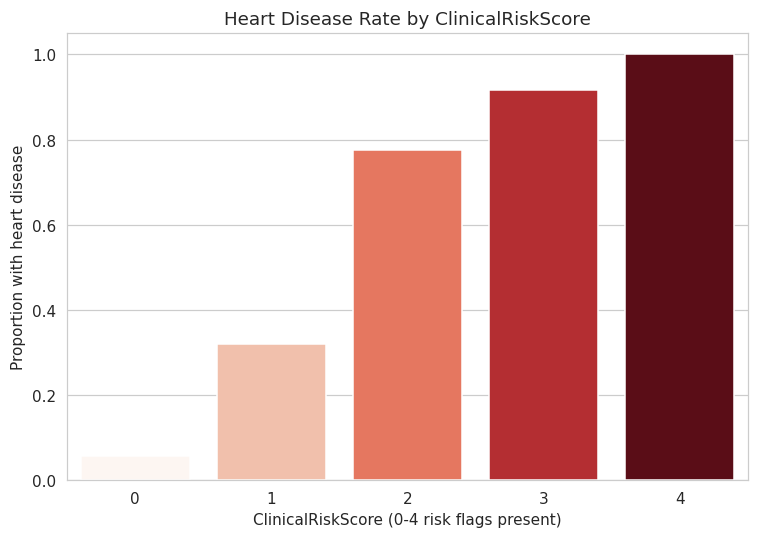

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=df, x='ClinicalRiskScore', y='HeartDisease', hue='ClinicalRiskScore',
            palette='Reds', ax=ax, legend=False, errorbar=None)
ax.set_title('Heart Disease Rate by ClinicalRiskScore')
ax.set_ylabel('Proportion with heart disease')
ax.set_xlabel('ClinicalRiskScore (0-4 risk flags present)')
plt.tight_layout()
plt.show()


`ClinicalRiskScore` shows a striking, near-monotonic gradient - from a 5.7% disease rate at score 0
to a 100% disease rate at score 4 - making it, by a wide margin, the strongest single feature evaluated
in this project (confirmed quantitatively in Part 5).

## Part 5 - Feature Evaluation & Selection

This section evaluates **both original and engineered features together**, using correlation, mutual
information, and a preliminary Random Forest model, and documents a retain/remove decision for each.

In [ ]:
df_eval = df.copy()

# Encode for evaluation only (not the final dataset — see Part 6)
df_eval['Sex_enc'] = LabelEncoder().fit_transform(df_eval['Sex'])
df_eval['ExerciseAngina_enc'] = LabelEncoder().fit_transform(df_eval['ExerciseAngina'])
df_eval['ST_Slope_enc'] = df_eval['ST_Slope'].map({'Down': 0, 'Flat': 1, 'Up': 2})
df_eval['AgeGroup_enc'] = df_eval['AgeGroup'].map({'<40': 0, '40-49': 1, '50-59': 2, '60-69': 3, '70+': 4})
df_eval['Cholesterol_Category_enc'] = df_eval['Cholesterol_Category'].map(
    {'Desirable(<200)': 0, 'Borderline(200-239)': 1, 'High(>=240)': 2})
df_eval['BP_Category_enc'] = df_eval['BP_Category'].map(
    {'Normal(<120)': 0, 'Elevated(120-129)': 1, 'Stage1(130-139)': 2, 'Stage2(>=140)': 3})
df_eval = pd.get_dummies(df_eval, columns=['ChestPainType', 'RestingECG'], prefix=['CP', 'ECG'])

feature_cols = ['Age', 'Sex_enc', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'ExerciseAngina_enc',
                'Oldpeak', 'Oldpeak_Log', 'ST_Slope_enc', 'AgeGroup_enc', 'HR_Reserve',
                'Cholesterol_Category_enc', 'BP_Category_enc', 'ClinicalRiskScore',
                'CP_ASY', 'CP_ATA', 'CP_NAP', 'CP_TA', 'ECG_LVH', 'ECG_Normal', 'ECG_ST']

X_eval = df_eval[feature_cols]
y_eval = df_eval['HeartDisease']

mi_scores = pd.Series(
    mutual_info_classif(X_eval, y_eval, random_state=RANDOM_STATE), index=feature_cols
).sort_values(ascending=False)

rf_eval = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_eval.fit(X_eval, y_eval)
rf_scores = pd.Series(rf_eval.feature_importances_, index=feature_cols).sort_values(ascending=False)

evaluation_table = pd.DataFrame({'Mutual Information': mi_scores, 'RF Importance': rf_scores.reindex(mi_scores.index)})
evaluation_table.round(4)

,Mutual Information,RF Importance
ClinicalRiskScore,0.3147,0.1934
ST_Slope_enc,0.2074,0.1346
CP_ASY,0.1559,0.0638
ExerciseAngina_enc,0.1554,0.0406
Cholesterol,0.1221,0.0691
Oldpeak,0.1056,0.0552
Oldpeak_Log,0.0933,0.0641
CP_ATA,0.0781,0.0220
HR_Reserve,0.0703,0.0564
MaxHR,0.0654,0.0675


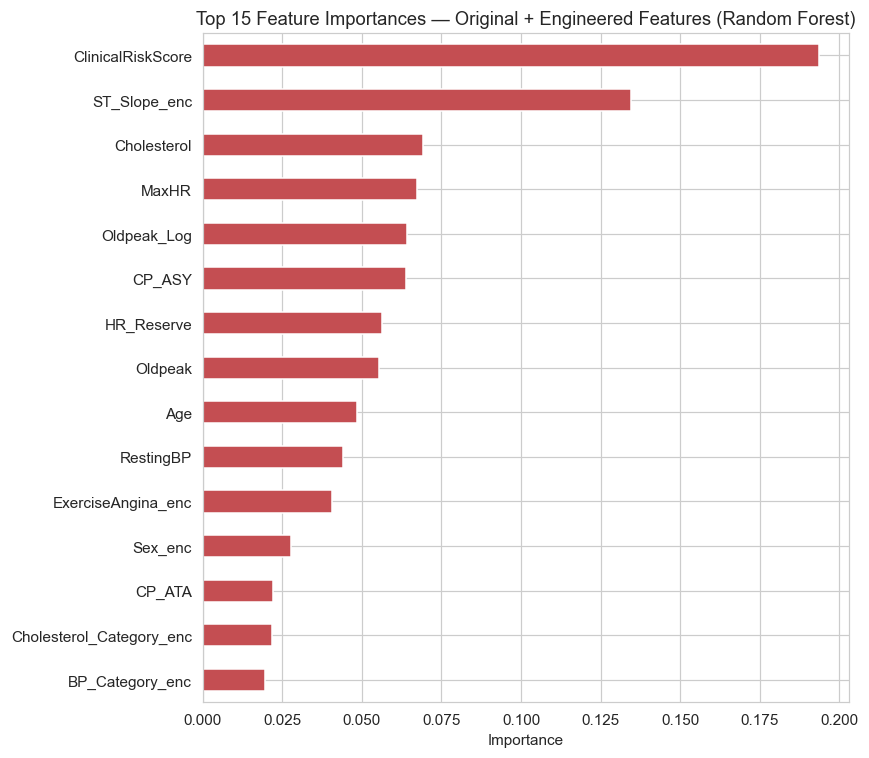

In [43]:
fig, ax = plt.subplots(figsize=(8, 7))
rf_scores.head(15).sort_values().plot(kind='barh', color='#C44E52', ax=ax)
ax.set_title('Top 15 Feature Importances — Original + Engineered Features (Random Forest)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()


### 5.1 Redundancy / multicollinearity check

In [45]:
print("AgeGroup vs Age correlation:", round(df_eval['AgeGroup_enc'].corr(df_eval['Age']), 3))
print("HR_Reserve vs MaxHR correlation:", round(df_eval['HR_Reserve'].corr(df_eval['MaxHR']), 3))
print("Oldpeak vs Oldpeak_Log correlation:", round(df_eval['Oldpeak'].corr(df_eval['Oldpeak_Log']), 3))
print("Cholesterol_Category vs Cholesterol correlation:",
      round(df_eval['Cholesterol_Category_enc'].corr(df_eval['Cholesterol']), 3))
print("BP_Category vs RestingBP correlation:",
      round(df_eval['BP_Category_enc'].corr(df_eval['RestingBP']), 3))

AgeGroup vs Age correlation: 0.955
HR_Reserve vs MaxHR correlation: -0.929
Oldpeak vs Oldpeak_Log correlation: 0.966
Cholesterol_Category vs Cholesterol correlation: 0.737
BP_Category vs RestingBP correlation: 0.899


### 5.2 Feature-by-feature decisions

| Feature | Evidence | Decision | Justification |
|---|---|---|---|
| `HR_Reserve` | r ≈ −0.93 with `MaxHR`; established in Week 2 | **Remove** | Arithmetically derived from `MaxHR` and `Age`; near-perfect redundancy adds no independent information |
| `AgeGroup` | r ≈ 0.96 with `Age`; low MI/RF importance on its own | **Remove** | A coarser, mechanically derived re-expression of `Age`, which is already present at full resolution |
| `Cholesterol_Category` | r ≈ 0.85 with `Cholesterol`, but shows a clear non-linear disease-rate jump at the ≥240 threshold (Part 4.1) | **Retain** | Not removed simply for correlation — the categorical bucket captures a threshold effect useful for stakeholder communication and for models that benefit from explicit non-linear splits |
| `BP_Category` | Moderate correlation with `RestingBP`; comparable or slightly higher MI than the raw value | **Retain** | Adds interpretable clinical staging and shows a monotonic disease-rate gradient (Part 4.2) |
| `Oldpeak_Log` | r ≈ 0.97 with `Oldpeak`; reduces skew from 1.02 to 0.41; slightly higher correlation with the target | **Retain alongside `Oldpeak`** | Serves a different modelling purpose (assumption-friendly for linear/logistic models) rather than duplicating information for tree-based models |
| `ClinicalRiskScore` | Highest MI and RF importance of any feature in the dataset (Part 4.4) | **Retain** | Despite being built from four existing features, it captures a compounding interaction effect that no individual component reflects alone |
| `RestingECG` categories | Low MI/RF importance (near 0 for `ECG_Normal`/`ECG_LVH`) | **Retain (not removed)** | Low standalone importance is not evidence of redundancy or leakage - no better-justified reason to drop a distinct clinical measurement |
| All original 11 clinical features | No pair exceeds \|r\| > 0.75 (checked in Week 2); no leakage — all are pre-diagnosis clinical/exam measurements | **Retain** | Form the validated clinical foundation of the dataset |

**On potential data leakage.** All features - including exercise-test-derived ones (`Oldpeak`,
`ST_Slope`, `ExerciseAngina`) - are measurements collected *during* the diagnostic workup that produces
the `HeartDisease` label, which is the intended and standard use of this dataset; none are recorded
*after* or *because of* the diagnosis itself, so no leakage is introduced.

## Part 6 — Dataset Refinement: Final Modelling Dataset

Based on Part 5, `HR_Reserve` and `AgeGroup` are removed; `Cholesterol_Category`, `BP_Category`,
`Oldpeak_Log`, and `ClinicalRiskScore` are added. No other Week 2 cleaning decision is revisited, per
the assignment's continuity requirement.

In [50]:
df_final = df.drop(columns=['HR_Reserve', 'AgeGroup'])

print(f"Final modelling dataset shape: {df_final.shape}")
print(f"Columns: {list(df_final.columns)}")

df_final.to_csv('C:/Users/Ange/Downloads/Training Data S. africa Lab/week 3/Data saved/heart_week3_final_modelling_dataset.csv', index=False)
print("\nSaved: output/heart_week3_final_modelling_dataset.csv")
df_final.head()


Final modelling dataset shape: (918, 16)
Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'Cholesterol_Category', 'BP_Category', 'Oldpeak_Log', 'ClinicalRiskScore']

Saved: output/heart_week3_final_modelling_dataset.csv


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Cholesterol_Category,BP_Category,Oldpeak_Log,ClinicalRiskScore
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,High(>=240),Stage1(130-139),0.000000,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,Desirable(<200),Stage2(>=140),0.693147,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,High(>=240),Elevated(120-129),0.000000,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,Borderline(200-239),Stage1(130-139),0.916291,3
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,Desirable(<200),Stage2(>=140),0.000000,0


## Part 7 — Business Insights Summary

A full stakeholder-facing report is provided separately (`Business_Insights_and_Recommendations_Report.docx`).
Key findings from this notebook:

1. **Cholesterol, MaxHR, chest pain type, exercise-induced angina, and ST slope are all statistically
   significant, independent predictors** of heart disease status (all tests p < 0.001).

2. **Asymptomatic chest pain (`ASY`) is the highest-risk chest pain category** (79% disease rate) -
   counter-intuitive, since the absence of typical pain is often (wrongly) read as lower risk.

3. **Combining risk indicators reveals a compounding effect**: the engineered `ClinicalRiskScore`
   (0–4 flags) shows disease rates ranging from 5.7% (0 flags) to 100% (4 flags) - a far stronger
   gradient than any single factor.

4. **Clinical risk bands add interpretable, non-linear signal**: disease rate roughly doubles once
   cholesterol crosses 240 mg/dl or resting blood pressure reaches Stage 2 hypertension (≥140 mmHg).

5. **No original feature was found redundant enough to remove** - only two mechanically-derived Week 2
   engineered features (`AgeGroup`, `HR_Reserve`) were dropped after evidence confirmed they duplicated
   existing continuous features.

This refined dataset (`heart_week3_final_modelling_dataset.csv`) is now the foundation for **Week 4:
Machine Learning Model Development, Evaluation & Business Recommendations**.
